# Postprocessing method comparison

Compares postprocessing strategies on the **training set** (LOAO CV) for all models.

| Method | Input | Description |
|--------|-------|-------------|
| `none` | hard labels | baseline — no postprocessing |
| `min_duration_filter` | hard labels | absorbs short segments into preceding class |
| `majority_vote_filter` | hard labels | symmetric sliding-window majority |
| `smooth_probs_argmax` | soft probabilities | smooth probs then argmax |
| `viterbi` | soft probabilities | 4-state HMM Viterbi decoding |

**Models**: XGBoost (pose), Image XGBoost, Pose TCN, Image TCN, ResNet — all evaluated via LOAO CV on the training set.

**Metrics**: macro F1, per-class F1, number/percentage of labels changed, gait event false positives/negatives.

In [81]:
# ── Models to evaluate ────────────────────────────────────────────────────────
# Valid keys: "xgboost", "img_xgb", "tcn", "img_tcn", "resnet"
ACTIVE_MODELS = ["xgboost", "img_xgb", "tcn", "img_tcn", "resnet"]

In [82]:
import joblib
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.metrics import per_class_f1
from src.gait.detection.postprocess import (
    estimate_hmm_params,
    min_duration_filter,
    majority_vote_filter,
    smooth_probs_argmax,
    viterbi_decode,
)
from src.gait.gait_data.dataset import load_dataset, loao_splits, train_test_split
from src.gait.image.dataset import load_image_dataset

# ── Cross-experiment paths (always optojump train → tempos test) ───────────────
OPTOJUMP_CSV = "data/output/annotations/optojump/visibility_annotations.csv"
TEMPOS_CSV   = "data/output/annotations/tempos/ml_labels.csv"

TCN_MANIFEST         = "data/output/gait/pose_data/stage6/manifest.json"
IMG_TCN_MANIFEST     = "data/output/gait/image/stage6/manifest.json"
RESNET_MANIFEST      = "data/output/gait/image/resnet/infer/manifest.json"

XGB_LOAO_MANIFEST     = "data/output/gait/pose_data/xgb_loao/manifest.json"
IMG_XGB_LOAO_MANIFEST = "data/output/gait/image/xgb_loao/manifest.json"
TCN_LOAO_MANIFEST     = "data/output/gait/pose_data/stage4/manifest.json"
IMG_TCN_LOAO_MANIFEST = "data/output/gait/image/stage4/manifest.json"
RESNET_LOAO_MANIFEST  = "data/output/gait/image/resnet/loao/manifest.json"

XGB_PARAMS_PATH    = "data/output/gait/pose_data/stage3/best_params.json"
XGB_CHECKPOINT_PATH = "data/output/gait/pose_data/stage3/checkpoints/model.pkl"
IMG_XGB_MODEL_PATH  = "data/output/gait/image/stage1/checkpoints/xgboost_best.pkl"

IMG_FEATURES_DIR        = "data/output/gait/image_features"
IMG_TEMPOS_FEATURES_DIR = "data/output/gait/image_features_tempos"
VIDEO_INPUT_DIR         = "data/input/optojump"

FPS     = 120.0
WINDOWS = [3, 5, 7, 9, 11]

In [83]:
import os, pathlib
_cwd = pathlib.Path.cwd()
if not (_cwd / "configs" / "dataset.yaml").exists():
    os.chdir(_cwd.parent)

In [84]:
# Pass annotations_csv explicitly so ExperimentConfig skips _load_dataset_params
# entirely — this notebook is always a cross experiment (optojump → tempos).
cfg = ExperimentConfig(annotations_csv=OPTOJUMP_CSV, fps=FPS, n_trim_padding=50)

train_records = load_dataset(OPTOJUMP_CSV, fps=cfg.fps, n_trim_padding=cfg.n_trim_padding)
test_records  = load_dataset(TEMPOS_CSV, fps=cfg.fps, dataset="tempos",
                             n_trim_padding=cfg.n_trim_padding)

print(f"Train : {len(train_records)} optojump records  ({len({r.athlete for r in train_records})} athletes)")
print(f"Test  : {len(test_records)} tempos records")

_IMAGE_METHODS = {"img_xgb", "img_tcn", "resnet"}
img_records_by_path = {}
img_tempos_by_path  = {}
if _IMAGE_METHODS & set(ACTIVE_MODELS):
    if os.path.exists(IMG_FEATURES_DIR):
        img_all = load_image_dataset(OPTOJUMP_CSV, IMG_FEATURES_DIR, VIDEO_INPUT_DIR,
                             n_trim_padding=cfg.n_trim_padding)
        img_records_by_path = {r.video_path: r for r in img_all}
        print(f"Image (train) : {len(img_all)} records loaded")
    if os.path.exists(IMG_TEMPOS_FEATURES_DIR):
        img_tempos = load_image_dataset(TEMPOS_CSV, IMG_TEMPOS_FEATURES_DIR,
                                        "data/input/tempos", dataset="tempos",
                                        n_trim_padding=cfg.n_trim_padding)
        img_tempos_by_path = {r.video_path: r for r in img_tempos}
        print(f"Image (test)  : {len(img_tempos)} tempos records loaded")

Train : 179 optojump records  (22 athletes)
Test  : 160 tempos records
Image (train) : 179 records loaded
Image (test)  : 160 tempos records loaded


## Helper functions

In [85]:
def apply_postprocessing(
    method: str,
    data: np.ndarray,
    window: int,
    hmm_params: dict | None = None,
) -> np.ndarray:
    """Dispatch to the right postprocessing function.

    `data` is a 1-D label array for hard-label methods,
    or a (T, n_classes) probability array for prob-based methods.
    `hmm_params` must be provided when method == "viterbi".
    """
    if method == "none":
        return data
    if method == "min_duration_filter":
        return min_duration_filter(data, min_frames=window)
    if method == "majority_vote_filter":
        return majority_vote_filter(data, window=window)
    if method == "smooth_probs_argmax":
        return smooth_probs_argmax(data, window=window)
    if method == "viterbi":
        return viterbi_decode(data, **hmm_params)
    raise ValueError(f"Unknown postprocessing method: {method!r}")


PROB_METHODS = frozenset({"smooth_probs_argmax", "viterbi"})

# Methods that have no window parameter (single evaluation point)
WINDOWLESS_METHODS = frozenset({"none", "viterbi"})

# All (method, window) combinations; windowless methods use window=0
METHODS_CONFIG = (
    [("none",    0)] +
    [("viterbi", 0)] +
    [("min_duration_filter",  w) for w in WINDOWS] +
    [("majority_vote_filter", w) for w in WINDOWS] +
    [("smooth_probs_argmax",  w) for w in WINDOWS]
)


def eval_fold_metrics(val_records, preds, raw_labels, n_classes, class_names):
    """Compute F1 and label-change count for one fold."""
    all_true, all_pred = [], []
    n_changed = 0
    n_total = 0

    for rec, pred, raw in zip(val_records, preds, raw_labels):
        all_true.append(rec.labels)
        all_pred.append(pred)
        n_changed += int(np.sum(pred != raw))
        n_total += len(pred)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return {
        "f1":        per_class_f1(y_true, y_pred, n_classes, class_names),
        "n_changed": n_changed,
        "n_total":   n_total,
    }

def _align_probs(probs: np.ndarray, target: int) -> np.ndarray:
    """Center-clip or edge-pad probs to match target label length."""
    t = probs.shape[0]
    if t == target: return probs
    if t > target:
        start = (t - target) // 2
        return probs[start : start + target]
    return np.pad(probs, ((0, target - t), (0, 0)), mode="edge")


In [86]:
STATE_NAMES = ["S_L", "F_L→R", "S_R", "F_R→L"]

startprob, transmat = estimate_hmm_params([r.labels for r in train_records])
HMM_PARAMS = {"transmat": transmat, "startprob": startprob}

print("HMM startprob:")
print(pd.Series(np.round(startprob, 4), index=STATE_NAMES).to_string())
print("\nHMM transmat (4-state):")
print(pd.DataFrame(np.round(transmat, 4), index=STATE_NAMES, columns=STATE_NAMES).to_string())

HMM startprob:
S_L      0.2235
F_L→R    0.2765
S_R      0.2235
F_R→L    0.2765

HMM transmat (4-state):
          S_L   F_L→R     S_R   F_R→L
S_L    0.9371  0.0629  0.0000  0.0000
F_L→R  0.0000  0.9237  0.0763  0.0000
S_R    0.0000  0.0000  0.9371  0.0629
F_R→L  0.0763  0.0000  0.0000  0.9237


---
## XGBoost — LOAO CV

For each fold: train on N-1 athletes, run `predict_proba` on the held-out athlete.  
Then apply every (method, window) combination and compute metrics.

In [87]:
_select = lambda features, idx: features if idx is None else features[:, idx]

xgb_fold_data = None
XGB_PARAMS = None
feature_idx = None

if "xgboost" not in ACTIVE_MODELS:
    print("XGBoost skipped (not in ACTIVE_MODELS).")
elif not os.path.exists(XGB_LOAO_MANIFEST):
    print(f"XGB LOAO manifest not found ({XGB_LOAO_MANIFEST}).\nRun pose_xgb_loao stage to enable comparison.")
else:
    with open(XGB_LOAO_MANIFEST) as f:
        xgb_loao_manifest = json.load(f)

    XGB_PARAMS  = xgb_loao_manifest["best_params"]
    feature_idx = xgb_loao_manifest.get("feature_idx")

    xgb_manifest_idx = {r["video_path"]: r for r in xgb_loao_manifest["records"]}

    xgb_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [r for r in fold_val if r.video_path in xgb_manifest_idx]
        probs      = [np.load(xgb_manifest_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        xgb_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })
    print(f"XGBoost LOAO manifest loaded  ({len(xgb_loao_manifest['records'])} records, {len(xgb_fold_data)} folds)")

XGBoost LOAO manifest loaded  (179 records, 22 folds)


In [88]:
xgb_results = {}  # (method, window) -> list[fold_result]

if xgb_fold_data is None:
    print("XGBoost LOAO not available — skipping.")
else:
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []

        for fold in xgb_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)

        xgb_results[(method, window)] = fold_results

    print(f"Computed {len(xgb_results)} (method, window) combinations for XGBoost.")


Computed 17 (method, window) combinations for XGBoost.


---
## Image XGBoost — LOAO CV

Loads per-fold softmax probabilities from the `img_xgb_loao` stage manifest.
Also loads the full trained model for test-set evaluation.


In [89]:
img_xgb_results = None
img_xgb_clf = None

if "img_xgb" not in ACTIVE_MODELS:
    print("Image XGBoost skipped (not in ACTIVE_MODELS).")
elif not os.path.exists(IMG_XGB_LOAO_MANIFEST):
    print(f"Image XGBoost LOAO manifest not found ({IMG_XGB_LOAO_MANIFEST}).\nRun img_xgb_loao stage to enable comparison.")
elif not img_records_by_path:
    print("Image records not loaded — skipping image XGBoost evaluation.")
else:
    with open(IMG_XGB_LOAO_MANIFEST) as f:
        img_xgb_loao_manifest = json.load(f)

    img_xgb_manifest_idx = {r["video_path"]: r for r in img_xgb_loao_manifest["records"]}

    img_xgb_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [
            img_records_by_path[r.video_path]
            for r in fold_val
            if r.video_path in img_records_by_path and r.video_path in img_xgb_manifest_idx
        ]
        probs      = [np.load(img_xgb_manifest_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        img_xgb_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Image XGBoost LOAO manifest loaded  ({len(img_xgb_loao_manifest['records'])} records, {len(img_xgb_fold_data)} folds)")

    img_xgb_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in img_xgb_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        img_xgb_results[(method, window)] = fold_results

    print(f"Computed {len(img_xgb_results)} (method, window) combinations for Image XGBoost.")

    if os.path.exists(IMG_XGB_MODEL_PATH):
        img_xgb_clf = joblib.load(IMG_XGB_MODEL_PATH)
        print(f"Loaded image XGBoost model for test evaluation: {IMG_XGB_MODEL_PATH}")

Image XGBoost LOAO manifest loaded  (179 records, 22 folds)
Computed 17 (method, window) combinations for Image XGBoost.
Loaded image XGBoost model for test evaluation: data/output/gait/image/stage1/checkpoints/xgboost_best.pkl


---
## Pose TCN — LOAO CV

Loads raw softmax probabilities from the LOAO manifest (held-out per-athlete predictions).

In [90]:
tcn_results = None

if "tcn" not in ACTIVE_MODELS:
    print("Pose TCN skipped (not in ACTIVE_MODELS).")
elif not os.path.exists(TCN_LOAO_MANIFEST):
    print(f"TCN LOAO manifest not found ({TCN_LOAO_MANIFEST}).\nRun the pose TCN LOAO stage to enable comparison.")
else:
    with open(TCN_LOAO_MANIFEST) as f:
        tcn_loao_manifest = json.load(f)

    tcn_loao_idx = {r["video_path"]: r for r in tcn_loao_manifest["records"]}

    tcn_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [r for r in fold_val if r.video_path in tcn_loao_idx]
        probs      = [np.load(tcn_loao_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        tcn_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Pose TCN LOAO manifest loaded  ({len(tcn_loao_manifest['records'])} records, {len(tcn_fold_data)} folds)")

    tcn_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in tcn_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        tcn_results[(method, window)] = fold_results

    print(f"Computed {len(tcn_results)} (method, window) combinations for Pose TCN.")

Pose TCN LOAO manifest loaded  (179 records, 22 folds)
Computed 17 (method, window) combinations for Pose TCN.


---
## Image TCN — LOAO CV

Loads raw softmax probabilities from the image TCN LOAO manifest (held-out per-athlete predictions).
Image records are used so that labels align with the image frame count.

In [91]:
img_tcn_results = None

if "img_tcn" not in ACTIVE_MODELS:
    print("Image TCN skipped (not in ACTIVE_MODELS).")
elif not os.path.exists(IMG_TCN_LOAO_MANIFEST):
    print(f"Image TCN LOAO manifest not found ({IMG_TCN_LOAO_MANIFEST}).\nRun img_tcn_loao stage to enable comparison.")
elif not img_records_by_path:
    print("Image records not loaded — skipping Image TCN evaluation.")
else:
    with open(IMG_TCN_LOAO_MANIFEST) as f:
        img_tcn_loao_manifest = json.load(f)

    img_tcn_loao_idx = {r["video_path"]: r for r in img_tcn_loao_manifest["records"]}

    img_tcn_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [
            img_records_by_path[r.video_path]
            for r in fold_val
            if r.video_path in img_records_by_path and r.video_path in img_tcn_loao_idx
        ]
        probs      = [np.load(img_tcn_loao_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        img_tcn_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Image TCN LOAO manifest loaded  ({len(img_tcn_loao_manifest['records'])} records, {len(img_tcn_fold_data)} folds)")

    img_tcn_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in img_tcn_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        img_tcn_results[(method, window)] = fold_results

    print(f"Computed {len(img_tcn_results)} (method, window) combinations for Image TCN.")

Image TCN LOAO manifest loaded  (179 records, 22 folds)
Computed 17 (method, window) combinations for Image TCN.


---
## ResNet linear head — LOAO CV

Loads per-fold softmax probabilities from the `img_resnet_loao` stage manifest.
Inference-manifest probs (full model) are used for test-set evaluation.


In [92]:
resnet_results = None
resnet_manifest_idx = {}
if os.path.exists(RESNET_MANIFEST):
    with open(RESNET_MANIFEST) as f:
        _resnet_infer_manifest = json.load(f)
    resnet_manifest_idx = {r["video_path"]: r for r in _resnet_infer_manifest["records"]}

if "resnet" not in ACTIVE_MODELS:
    print("ResNet skipped (not in ACTIVE_MODELS).")
elif not os.path.exists(RESNET_LOAO_MANIFEST):
    print(f"ResNet LOAO manifest not found ({RESNET_LOAO_MANIFEST}).\nRun img_resnet_loao stage to enable comparison.")
else:
    with open(RESNET_LOAO_MANIFEST) as f:
        resnet_loao_manifest = json.load(f)

    resnet_loao_idx = {r["video_path"]: r for r in resnet_loao_manifest["records"]}

    resnet_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        # ResNet processes frames directly — use pose records for labels.
        # Align probs to pose record label length (ResNet crops may differ by ±few frames).
        fold_val_m = [r for r in fold_val if r.video_path in resnet_loao_idx]
        probs      = [_align_probs(np.load(resnet_loao_idx[r.video_path]["probs_path"]),
                                   len(r.labels)) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        resnet_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"ResNet LOAO manifest loaded  ({len(resnet_loao_manifest['records'])} records, {len(resnet_fold_data)} folds)")

    resnet_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in resnet_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        resnet_results[(method, window)] = fold_results

    print(f"Computed {len(resnet_results)} (method, window) combinations for ResNet.")

ResNet LOAO manifest loaded  (179 records, 22 folds)
Computed 17 (method, window) combinations for ResNet.


---
## Build summary table

In [93]:
def build_summary(results_dict: dict, model_label: str) -> pd.DataFrame:
    rows = []
    for (method, window), folds in results_dict.items():
        macro_f1s = [f["f1"]["macro"] for f in folds]
        n_changed = sum(f["n_changed"] for f in folds)
        n_total   = sum(f["n_total"]   for f in folds)

        row = {
            "model":       model_label,
            "method":      method,
            "window":      window,
            "macro_f1":    float(np.mean(macro_f1s)),
            "n_changed":   n_changed,
            "pct_changed": 100.0 * n_changed / n_total if n_total > 0 else 0.0,
        }
        for cls in [k for k in folds[0]["f1"] if k != "macro"]:
            row[f"f1_{cls}"] = float(np.mean([f["f1"].get(cls, np.nan) for f in folds]))
        rows.append(row)
    return pd.DataFrame(rows)


dfs = [build_summary(xgb_results, "XGBoost")]
if img_xgb_results is not None:
    dfs.append(build_summary(img_xgb_results, "Image XGBoost"))
if tcn_results is not None:
    dfs.append(build_summary(tcn_results, "Pose TCN"))
if img_tcn_results is not None:
    dfs.append(build_summary(img_tcn_results, "Image TCN"))
if resnet_results is not None:
    dfs.append(build_summary(resnet_results, "ResNet linear head"))

summary = pd.concat(dfs, ignore_index=True)
summary["method_short"] = summary["method"].str.replace("_filter", "").str.replace("_argmax", "")

# delta_f1: improvement over the no-postprocessing baseline (positive = better)
baseline_f1 = (
    summary[summary["method"] == "none"]
    .set_index("model")["macro_f1"]
    .rename("_baseline_f1")
)
summary = summary.join(baseline_f1, on="model")
summary["delta_f1"] = summary["macro_f1"] - summary["_baseline_f1"]
summary = summary.drop(columns=["_baseline_f1"])

print(summary.to_string(index=False))

             model               method  window  macro_f1  n_changed  pct_changed  f1_left_stance  f1_right_stance  f1_flight  method_short  delta_f1
           XGBoost                 none       0  0.897292          0     0.000000        0.897492         0.901307   0.893077          none  0.000000
           XGBoost              viterbi       0  0.896837        219     1.195219        0.897598         0.902302   0.890611       viterbi -0.000455
           XGBoost  min_duration_filter       3  0.897966        168     0.916880        0.901607         0.899453   0.892837  min_duration  0.000674
           XGBoost  min_duration_filter       5  0.892147        450     2.455930        0.897539         0.894726   0.884175  min_duration -0.005145
           XGBoost  min_duration_filter       7  0.878502        915     4.993724        0.885562         0.882171   0.867771  min_duration -0.018790
           XGBoost  min_duration_filter       9  0.843877       1721     9.392567        0.849695   

In [94]:
summary[summary['method_short'] == 'viterbi']

,model,method,window,macro_f1,n_changed,pct_changed,f1_left_stance,f1_right_stance,f1_flight,method_short,delta_f1
1,XGBoost,viterbi,0,0.896837,219,1.195219,0.897598,0.902302,0.890611,viterbi,-0.000455
18,Image XGBoost,viterbi,0,0.856325,1954,10.640963,0.843078,0.861557,0.864339,viterbi,0.074354
35,Pose TCN,viterbi,0,0.910283,141,0.769525,0.914154,0.915120,0.901575,viterbi,-0.001362
52,Image TCN,viterbi,0,0.893577,432,2.352557,0.896483,0.891162,0.893085,viterbi,0.002176
69,ResNet linear head,viterbi,0,0.923465,410,2.237625,0.922982,0.920360,0.927053,viterbi,0.015575


---
## Visualisation

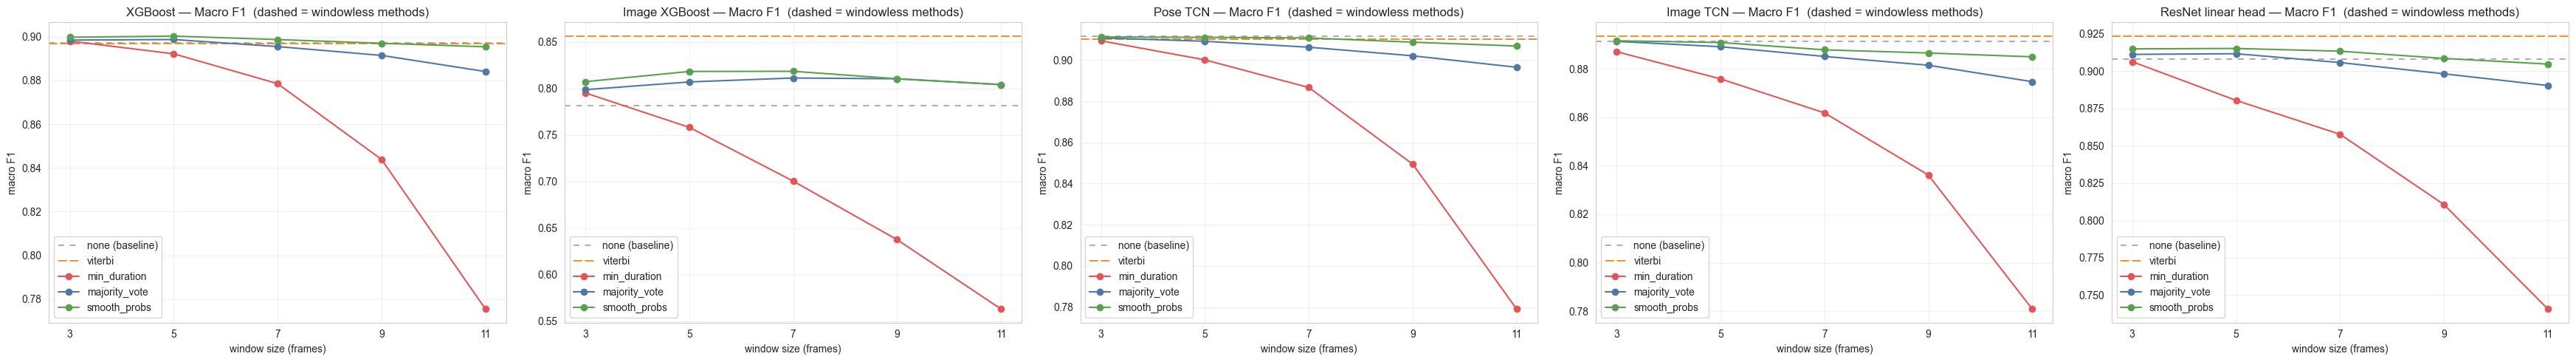

In [95]:
METHOD_COLORS = {
    "none":                 "#aaaaaa",
    "viterbi":              "#f28e2b",
    "min_duration_filter":  "#e15759",
    "majority_vote_filter": "#4e79a7",
    "smooth_probs_argmax":  "#59a14f",
}
METHOD_LABELS = {
    "none":                 "none (baseline)",
    "viterbi":              "viterbi",
    "min_duration_filter":  "min_duration",
    "majority_vote_filter": "majority_vote",
    "smooth_probs_argmax":  "smooth_probs",
}
LINE_STYLES = {
    "none":    (0, (4, 4)),   # dashed, gray
    "viterbi": (0, (6, 2)),   # long-dash, orange
}


def _plot_f1_lines(df, models, metric, ylabel, title):
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df["model"] == model].copy()
        for method, grp in sub.groupby("method", sort=False):
            color = METHOD_COLORS[method]
            label = METHOD_LABELS[method]
            if method in WINDOWLESS_METHODS:
                val = grp[metric].iloc[0]
                ax.axhline(val, color=color, linestyle=LINE_STYLES[method],
                           linewidth=1.4, label=label, zorder=0)
            else:
                grp = grp.sort_values("window")
                ax.plot(grp["window"], grp[metric], marker="o",
                        color=color, label=label)
        ax.set_xlabel("window size (frames)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{model} — {title}")
        ax.set_xticks(WINDOWS)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


models_present = summary["model"].unique().tolist()

_plot_f1_lines(summary, models_present, "macro_f1",
               ylabel="macro F1",
               title="Macro F1  (dashed = windowless methods)")

In [96]:
def plot_labels_changed(model_label):
    # Windowless methods have no meaningful x-axis, so exclude them from the line plot
    sub = summary[
        (summary["model"] == model_label) &
        (~summary["method"].isin(WINDOWLESS_METHODS))
    ].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    for method, grp in sub.groupby("method", sort=False):
        grp = grp.sort_values("window")
        ax.plot(grp["window"], grp["pct_changed"], marker="o",
                color=METHOD_COLORS[method], label=METHOD_LABELS[method])

    # Add windowless methods as horizontal reference lines
    wl = summary[(summary["model"] == model_label) & (summary["method"].isin(WINDOWLESS_METHODS))]
    for _, row in wl.iterrows():
        ax.axhline(row["pct_changed"], color=METHOD_COLORS[row["method"]],
                   linestyle=LINE_STYLES[row["method"]], linewidth=1.4,
                   label=METHOD_LABELS[row["method"]])

    ax.set_xlabel("window size (frames)")
    ax.set_ylabel("labels changed (%)")
    ax.set_title(f"{model_label} — % of labels changed by postprocessing")
    ax.set_xticks(WINDOWS)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# for m in models_present:
#     plot_labels_changed(m)

# Summary table
# display(
#     summary[["model", "method", "window", "n_changed", "pct_changed", "macro_f1", "delta_f1"]]
#     .sort_values(["model", "method", "window"])
#     .reset_index(drop=True)
#     .style.format({"pct_changed": "{:.2f}%", "macro_f1": "{:.4f}", "delta_f1": "{:+.4f}"})
# )

---
## Best configuration per model

Rank postprocessed configurations by macro F1 (descending).
The no-postprocessing baseline (`none`) is shown first for reference.

In [97]:
f1_cols = [c for c in summary.columns if c.startswith("f1_")]

# No-postprocessing baseline
baseline = (
    summary[summary["method"] == "none"]
    .groupby("model", sort=False)[["macro_f1"] + f1_cols]
    .mean()
    .reset_index()
    .rename(columns={"macro_f1": "baseline_macro_f1"})
)
print("Baseline (no postprocessing):")
display(baseline)

# Best postprocessed config per model (highest macro F1)
best = (
    summary[summary["method"] != "none"]
    .sort_values("macro_f1", ascending=False)
    .groupby("model", sort=False)
    .first()
    [["method", "window", "macro_f1", "pct_changed"] + f1_cols]
    .reset_index()
)
print("\nBest postprocessed config per model:")
display(best)

Baseline (no postprocessing):


,model,baseline_macro_f1,f1_left_stance,f1_right_stance,f1_flight
0,XGBoost,0.897292,0.897492,0.901307,0.893077
1,Image XGBoost,0.781970,0.729129,0.759720,0.857061
2,Pose TCN,0.911645,0.914736,0.915503,0.904695
3,Image TCN,0.891401,0.889198,0.883828,0.901176
4,ResNet linear head,0.907890,0.899420,0.899350,0.924899



Best postprocessed config per model:


,model,method,window,macro_f1,pct_changed,f1_left_stance,f1_right_stance,f1_flight
0,ResNet linear head,viterbi,0,0.923465,2.237625,0.922982,0.920360,0.927053
1,Pose TCN,smooth_probs_argmax,3,0.911228,0.327457,0.914467,0.915506,0.903710
2,XGBoost,smooth_probs_argmax,5,0.900240,1.500846,0.901177,0.903022,0.896521
3,Image TCN,viterbi,0,0.893577,2.352557,0.896483,0.891162,0.893085
4,Image XGBoost,viterbi,0,0.856325,10.640963,0.843078,0.861557,0.864339


---
## Test set evaluation

For each model: apply **no postprocessing** (baseline), **Viterbi**, and the **best windowed method**
selected on the training set (best macro F1 among `min_duration_filter`, `majority_vote_filter`,
`smooth_probs_argmax` across all window sizes).

XGBoost is retrained on all train athletes before predicting on the held-out test athletes.
All other models load their saved test-split probabilities from the inference manifests.

In [98]:
test_model_data = {}  # model_label -> {val_records, raw_labels, probs}

# ── XGBoost ───────────────────────────────────────────────────────────────────
if "xgboost" in ACTIVE_MODELS and XGB_PARAMS is not None:
    import joblib as _jl
    if os.path.exists(XGB_CHECKPOINT_PATH):
        clf_full = _jl.load(XGB_CHECKPOINT_PATH)
        print(f"XGBoost: loaded checkpoint from {XGB_CHECKPOINT_PATH}")
    else:
        X_tr = np.vstack([_select(r.features, feature_idx) for r in train_records])
        y_tr = np.concatenate([r.labels for r in train_records])
        clf_full = xgb.XGBClassifier(
            **XGB_PARAMS, eval_metric="mlogloss", tree_method="hist", device="cpu", verbosity=0,
        )
        clf_full.fit(X_tr, y_tr)
        print(f"XGBoost: retrained on {len(train_records)} train records")
    xgb_test_probs  = [clf_full.predict_proba(_select(r.features, feature_idx)) for r in test_records]
    xgb_test_labels = [p.argmax(axis=1).astype(np.int64) for p in xgb_test_probs]
    test_model_data["XGBoost"] = {
        "val_records": test_records, "raw_labels": xgb_test_labels, "probs": xgb_test_probs,
    }
    print(f"XGBoost: {len(test_records)} tempos test records")

# ── Image XGBoost ─────────────────────────────────────────────────────────────
if "img_xgb" in ACTIVE_MODELS and img_xgb_clf is not None and img_tempos_by_path:
    img_xgb_test_recs  = [img_tempos_by_path[r.video_path] for r in test_records
                          if r.video_path in img_tempos_by_path]
    img_xgb_test_probs  = [img_xgb_clf.predict_proba(r.features) for r in img_xgb_test_recs]
    img_xgb_test_labels = [p.argmax(axis=1).astype(np.int64) for p in img_xgb_test_probs]
    test_model_data["Image XGBoost"] = {
        "val_records": img_xgb_test_recs, "raw_labels": img_xgb_test_labels, "probs": img_xgb_test_probs,
    }
    print(f"Image XGBoost: {len(img_xgb_test_recs)} tempos test records")

# ── Pose TCN ──────────────────────────────────────────────────────────────────
if "tcn" in ACTIVE_MODELS and os.path.exists(TCN_MANIFEST):
    with open(TCN_MANIFEST) as f:
        _tcn_infer = json.load(f)
    _tcn_infer_idx = {r["video_path"]: r for r in _tcn_infer["records"]}
    tcn_test_recs = [r for r in test_records if r.video_path in _tcn_infer_idx]
    if tcn_test_recs:
        tcn_test_probs  = [_align_probs(np.load(_tcn_infer_idx[r.video_path]["probs_path"]),
                                        len(r.labels)) for r in tcn_test_recs]
        tcn_test_labels = [p.argmax(axis=1).astype(np.int64) for p in tcn_test_probs]
        test_model_data["Pose TCN"] = {
            "val_records": tcn_test_recs, "raw_labels": tcn_test_labels, "probs": tcn_test_probs,
        }
        print(f"Pose TCN: {len(tcn_test_recs)} tempos test records")

# ── Image TCN ─────────────────────────────────────────────────────────────────
if "img_tcn" in ACTIVE_MODELS and os.path.exists(IMG_TCN_MANIFEST) and img_tempos_by_path:
    with open(IMG_TCN_MANIFEST) as f:
        _img_tcn_infer = json.load(f)
    _img_tcn_infer_idx = {r["video_path"]: r for r in _img_tcn_infer["records"]}
    img_tcn_test_recs = [
        img_tempos_by_path[r.video_path] for r in test_records
        if r.video_path in _img_tcn_infer_idx and r.video_path in img_tempos_by_path
    ]
    if img_tcn_test_recs:
        img_tcn_test_probs  = [_align_probs(np.load(_img_tcn_infer_idx[r.video_path]["probs_path"]),
                                            len(r.labels)) for r in img_tcn_test_recs]
        img_tcn_test_labels = [p.argmax(axis=1).astype(np.int64) for p in img_tcn_test_probs]
        test_model_data["Image TCN"] = {
            "val_records": img_tcn_test_recs, "raw_labels": img_tcn_test_labels, "probs": img_tcn_test_probs,
        }
        print(f"Image TCN: {len(img_tcn_test_recs)} tempos test records")

# ── ResNet ────────────────────────────────────────────────────────────────────
if "resnet" in ACTIVE_MODELS and resnet_manifest_idx:
    resnet_test_recs = [r for r in test_records if r.video_path in resnet_manifest_idx]
    if resnet_test_recs:
        resnet_test_probs  = [_align_probs(np.load(resnet_manifest_idx[r.video_path]["probs_path"]),
                                           len(r.labels)) for r in resnet_test_recs]
        resnet_test_labels = [p.argmax(axis=1).astype(np.int64) for p in resnet_test_probs]
        test_model_data["ResNet linear head"] = {
            "val_records": resnet_test_recs, "raw_labels": resnet_test_labels, "probs": resnet_test_probs,
        }
        print(f"ResNet: {len(resnet_test_recs)} tempos test records")


XGBoost: loaded checkpoint from data/output/gait/pose_data/stage3/checkpoints/model.pkl
XGBoost: 160 tempos test records
Image XGBoost: 160 tempos test records
Pose TCN: 160 tempos test records
Image TCN: 160 tempos test records
ResNet: 160 tempos test records


In [99]:
# Best windowed method per model, chosen on training set (excludes viterbi / none)
WINDOWED_METHODS = {"min_duration_filter", "majority_vote_filter", "smooth_probs_argmax"}
best_window_train = (
    summary[summary["method"].isin(WINDOWED_METHODS)]
    .sort_values("macro_f1", ascending=False)
    .groupby("model", sort=False)
    .first()
    [["method", "window"]]
)


def _eval_on_test(data, method, window):
    needs_probs = method in PROB_METHODS
    preds = [
        apply_postprocessing(
            method,
            data["probs"][i] if needs_probs else data["raw_labels"][i],
            window,
            hmm_params=HMM_PARAMS,
        )
        for i in range(len(data["val_records"]))
    ]
    return eval_fold_metrics(
        data["val_records"], preds, data["raw_labels"],
        cfg.n_classes, cfg.class_names,
    )


rows = []
for model_label, data in test_model_data.items():
    base_f1 = _eval_on_test(data, "none",    0)["f1"]["macro"]
    vit_f1  = _eval_on_test(data, "viterbi", 0)["f1"]["macro"]

    if model_label in best_window_train.index:
        bw_method = best_window_train.loc[model_label, "method"]
        bw_window = int(best_window_train.loc[model_label, "window"])
        bw_f1     = _eval_on_test(data, bw_method, bw_window)["f1"]["macro"]
        bw_label  = f"{bw_method.replace('_filter','').replace('_argmax','')}  w={bw_window}"
    else:
        bw_f1, bw_label = float("nan"), "n/a (no LOAO)"

    rows.append({
        "model":             model_label,
        "baseline_f1":       base_f1,
        "viterbi_f1":        vit_f1,
        "viterbi_Δ":         vit_f1  - base_f1,
        "best_window":       bw_label,
        "best_window_f1":    bw_f1,
        "best_window_Δ":     bw_f1   - base_f1,
    })

test_cmp = pd.DataFrame(rows)
display(
    test_cmp.style.format({
        "baseline_f1":    "{:.4f}",
        "viterbi_f1":     "{:.4f}",
        "viterbi_Δ":      "{:+.4f}",
        "best_window_f1": "{:.4f}",
        "best_window_Δ":  "{:+.4f}",
    })
)

,model,baseline_f1,viterbi_f1,viterbi_Δ,best_window,best_window_f1,best_window_Δ
0,XGBoost,0.8226,0.8283,+0.0057,smooth_probs w=5,0.8271,+0.0045
1,Image XGBoost,0.3754,0.3698,-0.0056,smooth_probs w=7,0.3882,+0.0129
2,Pose TCN,0.7492,0.7433,-0.0059,smooth_probs w=3,0.7499,+0.0007
3,Image TCN,0.3861,0.3747,-0.0114,smooth_probs w=3,0.3824,-0.0037
4,ResNet linear head,0.5415,0.5660,+0.0245,smooth_probs w=5,0.5501,+0.0086


---
## Event detection errors: false positives and false negatives

Events are derived from label-sequence transitions.
A predicted event matches a ground-truth event if within **±5 frames** (greedy nearest-neighbour).

- **FP** — spurious detection (no matching annotation event)
- **FN** — missed detection (no matching predicted event)
- **MAE** — mean absolute timing error of matched events (frames and ms)

Results for **Train (LOAO CV on optojump)** and **Test (tempos)**.

In [100]:
from src.gait.detection.postprocess import derive_events

EVENT_KEYS   = ["left_landing", "left_takeoff", "right_landing", "right_takeoff"]
TOLERANCE_FR = 5
TOLERANCE_S  = TOLERANCE_FR / cfg.fps
print(f"Event matching tolerance: {TOLERANCE_FR} frames  =  {TOLERANCE_S * 1000:.1f} ms")


def _match_events(pred_times, true_times, tol):
    pred_matched, true_matched = set(), set()
    timing_errors = []
    for i, pt in enumerate(pred_times):
        if len(true_times) == 0:
            break
        dists = np.abs(true_times - pt)
        cands = [j for j in np.where(dists <= tol)[0] if j not in true_matched]
        if cands:
            best = cands[int(np.argmin(dists[np.array(cands)]))]
            pred_matched.add(i)
            true_matched.add(best)
            timing_errors.append(float(abs(pt - true_times[best])))
    return len(pred_times) - len(pred_matched), len(true_times) - len(true_matched), timing_errors


def _event_errors(true_labels, pred_labels, fps, tol):
    true_ev = derive_events(true_labels, fps)
    pred_ev = derive_events(pred_labels, fps)
    out = {}
    for k in EVENT_KEYS:
        fp, fn, terrs = _match_events(pred_ev[k], true_ev[k], tol)
        out[k] = {"fp": fp, "fn": fn, "timing_errors_s": terrs}
    all_terrs = [e for k in EVENT_KEYS for e in out[k]["timing_errors_s"]]
    out["total"] = {
        "fp": sum(out[k]["fp"] for k in EVENT_KEYS),
        "fn": sum(out[k]["fn"] for k in EVENT_KEYS),
        "timing_errors_s": all_terrs,
    }
    return out


def _aggregate_event_errors_loao(fold_data, use_viterbi):
    """Aggregate over LOAO folds (training set)."""
    totals = {k: {"fp": 0, "fn": 0, "timing_errors_s": []} for k in EVENT_KEYS + ["total"]}
    for fold in fold_data:
        for i, rec in enumerate(fold["val_records"]):
            pred = (viterbi_decode(fold["probs"][i], **HMM_PARAMS)
                    if use_viterbi else fold["raw_labels"][i])
            for k, v in _event_errors(rec.labels, pred, cfg.fps, TOLERANCE_S).items():
                totals[k]["fp"] += v["fp"]
                totals[k]["fn"] += v["fn"]
                totals[k]["timing_errors_s"].extend(v["timing_errors_s"])
    return totals


def _aggregate_event_errors_test(test_data, use_viterbi):
    """Aggregate over flat test set (tempos)."""
    totals = {k: {"fp": 0, "fn": 0, "timing_errors_s": []} for k in EVENT_KEYS + ["total"]}
    for i, rec in enumerate(test_data["val_records"]):
        pred = (viterbi_decode(test_data["probs"][i], **HMM_PARAMS)
                if use_viterbi else test_data["raw_labels"][i])
        for k, v in _event_errors(rec.labels, pred, cfg.fps, TOLERANCE_S).items():
            totals[k]["fp"] += v["fp"]
            totals[k]["fn"] += v["fn"]
            totals[k]["timing_errors_s"].extend(v["timing_errors_s"])
    return totals


def _pct_change(before, after):
    return (after - before) / before * 100 if before != 0 else float("nan")


def _event_rows(model_name, raw, vit):
    rows = []
    for k in EVENT_KEYS + ["total"]:
        fp_b, fp_a = raw[k]["fp"], vit[k]["fp"]
        fn_b, fn_a = raw[k]["fn"], vit[k]["fn"]
        raw_te, vit_te = raw[k]["timing_errors_s"], vit[k]["timing_errors_s"]
        rows.append({
            "Model":            model_name,
            "Event":            k.replace("_", " "),
            "FP (raw)":         fp_b,
            "FP (vit)":         fp_a,
            "FP \u0394%":      _pct_change(fp_b, fp_a),
            "FN (raw)":         fn_b,
            "FN (vit)":         fn_a,
            "FN \u0394%":      _pct_change(fn_b, fn_a),
            "MAE fr (raw)":     round(np.mean(raw_te) * cfg.fps, 2) if raw_te else float("nan"),
            "MAE ms (raw)":     round(np.mean(raw_te) * 1000, 2)    if raw_te else float("nan"),
            "MAE fr (vit)":     round(np.mean(vit_te) * cfg.fps, 2) if vit_te else float("nan"),
            "MAE ms (vit)":     round(np.mean(vit_te) * 1000, 2)    if vit_te else float("nan"),
        })
    return rows


def _display_event_table(df, model_name):
    sub = df[df["Model"] == model_name].set_index("Event")
    display(sub.style.format({
        "FP \u0394%":  lambda v: f"{v:+.1f}%" if not pd.isna(v) else "\u2014",
        "FN \u0394%":  lambda v: f"{v:+.1f}%" if not pd.isna(v) else "\u2014",
        "MAE fr (raw)": lambda v: f"{v:.2f}"   if not pd.isna(v) else "\u2014",
        "MAE ms (raw)": lambda v: f"{v:.2f}"   if not pd.isna(v) else "\u2014",
        "MAE fr (vit)": lambda v: f"{v:.2f}"   if not pd.isna(v) else "\u2014",
        "MAE ms (vit)": lambda v: f"{v:.2f}"   if not pd.isna(v) else "\u2014",
    }))


# ── Training (LOAO CV on optojump) ────────────────────────────────────────────
_fold_datasets = {}
if xgb_fold_data is not None:      _fold_datasets["XGBoost"]           = xgb_fold_data
if img_xgb_results is not None:    _fold_datasets["Image XGBoost"]     = img_xgb_fold_data
if tcn_results is not None:        _fold_datasets["Pose TCN"]          = tcn_fold_data
if img_tcn_results is not None:    _fold_datasets["Image TCN"]         = img_tcn_fold_data
if resnet_results is not None:     _fold_datasets["ResNet linear head"] = resnet_fold_data

train_event_rows = []
for model_name, fdata in _fold_datasets.items():
    raw = _aggregate_event_errors_loao(fdata, use_viterbi=False)
    vit = _aggregate_event_errors_loao(fdata, use_viterbi=True)
    train_event_rows.extend(_event_rows(model_name, raw, vit))
train_event_df = pd.DataFrame(train_event_rows)

print("\n=== Train (LOAO CV — optojump) ===")
for model_name in _fold_datasets:
    print(f"\n\u2500\u2500 {model_name} \u2500\u2500")
    _display_event_table(train_event_df, model_name)

# ── Test (tempos) ─────────────────────────────────────────────────────────────
test_event_rows = []
for model_name, tdata in test_model_data.items():
    raw = _aggregate_event_errors_test(tdata, use_viterbi=False)
    vit = _aggregate_event_errors_test(tdata, use_viterbi=True)
    test_event_rows.extend(_event_rows(model_name, raw, vit))
test_event_df = pd.DataFrame(test_event_rows)

print("\n=== Test (tempos) ===")
for model_name in test_model_data:
    print(f"\n\u2500\u2500 {model_name} \u2500\u2500")
    _display_event_table(test_event_df, model_name)


Event matching tolerance: 5 frames  =  41.7 ms

=== Train (LOAO CV — optojump) ===

── XGBoost ──


,Model,FP (raw),FP (vit),FP Δ%,FN (raw),FN (vit),FN Δ%,MAE fr (raw),MAE ms (raw),MAE fr (vit),MAE ms (vit)
Event,,,,,,,,,,,
left landing,XGBoost,48,33,-31.2%,32,38,+18.8%,1.02,8.50,1.05,8.75
left takeoff,XGBoost,54,28,-48.1%,22,30,+36.4%,0.86,7.14,0.84,6.97
right landing,XGBoost,38,21,-44.7%,25,28,+12.0%,0.98,8.18,0.99,8.28
right takeoff,XGBoost,33,28,-15.2%,27,40,+48.1%,0.85,7.05,0.83,6.93
total,XGBoost,173,110,-36.4%,106,136,+28.3%,0.93,7.72,0.93,7.74



── Image XGBoost ──


,Model,FP (raw),FP (vit),FP Δ%,FN (raw),FN (vit),FN Δ%,MAE fr (raw),MAE ms (raw),MAE fr (vit),MAE ms (vit)
Event,,,,,,,,,,,
left landing,Image XGBoost,346,41,-88.2%,84,41,-51.2%,1.26,10.53,1.25,10.44
left takeoff,Image XGBoost,355,46,-87.0%,55,40,-27.3%,1.50,12.47,1.35,11.27
right landing,Image XGBoost,205,31,-84.9%,105,33,-68.6%,1.17,9.74,1.17,9.71
right takeoff,Image XGBoost,176,33,-81.2%,93,33,-64.5%,1.23,10.26,1.13,9.38
total,Image XGBoost,1082,151,-86.0%,337,147,-56.4%,1.30,10.82,1.22,10.20



── Pose TCN ──


...

,Model,FP (raw),FP (vit),FP Δ%,FN (raw),FN (vit),FN Δ%,MAE fr (raw),MAE ms (raw),MAE fr (vit),MAE ms (vit)
Event,,,,,,,,,,,
left landing,Pose TCN,54,117,+116.7%,137,131,-4.4%,1.56,13.03,1.57,13.10
left takeoff,Pose TCN,74,136,+83.8%,129,132,+2.3%,1.26,10.52,1.26,10.48
right landing,Pose TCN,141,135,-4.3%,109,131,+20.2%,1.48,12.33,1.43,11.95
right takeoff,Pose TCN,131,88,-32.8%,103,74,-28.2%,1.73,14.43,1.80,15.04
total,Pose TCN,400,476,+19.0%,478,468,-2.1%,1.51,12.61,1.53,12.76



── Image TCN ──


,Model,FP (raw),FP (vit),FP Δ%,FN (raw),FN (vit),FN Δ%,MAE fr (raw),MAE ms (raw),MAE fr (vit),MAE ms (vit)
Event,,,,,,,,,,,
left landing,Image TCN,343,262,-23.6%,326,275,-15.6%,2.66,22.20,2.42,20.20
left takeoff,Image TCN,337,252,-25.2%,387,375,-3.1%,3.23,26.93,2.88,24.02
right landing,Image TCN,138,213,+54.3%,365,325,-11.0%,2.08,17.32,2.29,19.07
right takeoff,Image TCN,212,321,+51.4%,385,336,-12.7%,3.00,25.00,2.54,21.18
total,Image TCN,1030,1048,+1.7%,1463,1311,-10.4%,2.71,22.59,2.49,20.75



── ResNet linear head ──


,Model,FP (raw),FP (vit),FP Δ%,FN (raw),FN (vit),FN Δ%,MAE fr (raw),MAE ms (raw),MAE fr (vit),MAE ms (vit)
Event,,,,,,,,,,,
left landing,ResNet linear head,152,227,+49.3%,334,188,-43.7%,1.87,15.61,1.97,16.41
left takeoff,ResNet linear head,126,285,+126.2%,370,270,-27.0%,1.86,15.51,1.52,12.65
right landing,ResNet linear head,745,266,-64.3%,129,196,+51.9%,1.98,16.47,1.92,16.02
right takeoff,ResNet linear head,843,286,-66.1%,186,217,+16.7%,2.31,19.27,2.30,19.19
total,ResNet linear head,1866,1064,-43.0%,1019,871,-14.5%,2.07,17.22,1.95,16.28


---
## Summary tables

Total event counts and timing errors across all event types, for raw argmax vs Viterbi.
Train = optojump LOAO CV; Test = tempos.

In [101]:
def _summary_table(event_df):
    """Extract the 'total' row per model and pivot into a clean summary."""
    tot = event_df[event_df["Event"] == "total"].copy().set_index("Model")
    return tot[[
        "FP (raw)", "FP (vit)", "FN (raw)", "FN (vit)",
        "MAE fr (raw)", "MAE ms (raw)", "MAE fr (vit)", "MAE ms (vit)",
    ]]

print("=== Train (LOAO CV — optojump) ===")
print(_summary_table(train_event_df))

print("\n=== Test (tempos) ===")
print(_summary_table(test_event_df))


=== Train (LOAO CV — optojump) ===
                    FP (raw)  FP (vit)  FN (raw)  FN (vit)  MAE fr (raw)  \
Model                                                                      
XGBoost                  173       110       106       136          0.93   
Image XGBoost           1082       151       337       147          1.30   
Pose TCN                  93        76       101       132          0.83   
Image TCN                166        63       149       174          0.90   
ResNet linear head       314       133       114        72          0.55   

                    MAE ms (raw)  MAE fr (vit)  MAE ms (vit)  
Model                                                         
XGBoost                     7.72          0.93          7.74  
Image XGBoost              10.82          1.22         10.20  
Pose TCN                    6.92          0.83          6.95  
Image TCN                   7.51          0.89          7.41  
ResNet linear head          4.59          0.55        